# Book Popularity Prediction — Clean Machine Learning Notebook

## Project objective

In this project, we build a Machine Learning model that predicts whether a book is:

- **Popular**
- **Unpopular**

The dataset contains information about books, reviews, descriptions, categories, authors, prices, and popularity.

At the end, we save the trained model so it can be used later inside a **Flask web application**.


## 1. Import libraries

We use:

- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for preprocessing, training, and evaluation
- `joblib` to save the trained model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score


## 2. Load the dataset

The dataset file is named `books.csv`.

If your file is inside a folder named `data`, use:

```python
books = pd.read_csv("data/books.csv")
```


In [ ]:
# Load dataset
books = pd.read_csv("books.csv")

# Display first rows
books.head()

,title,price,review/helpfulness,review/summary,review/text,description,authors,categories,popularity
0,We Band of Angels: The Untold Story of America...,10.88,2/3,A Great Book about women in WWII,I have alway been a fan of fiction books set i...,"In the fall of 1941, the Philippines was a gar...",'Elizabeth Norman','History',Unpopular
1,Prayer That Brings Revival: Interceding for Go...,9.35,0/0,Very helpful book for church prayer groups and...,Very helpful book to give you a better prayer ...,"In Prayer That Brings Revival, best-selling au...",'Yong-gi Cho','Religion',Unpopular
2,The Mystical Journey from Jesus to Christ,24.95,17/19,Universal Spiritual Awakening Guide With Some ...,The message of this book is to find yourself a...,THE MYSTICAL JOURNEY FROM JESUS TO CHRIST Disc...,'Muata Ashby',"'Body, Mind & Spirit'",Unpopular
3,Death Row,7.99,0/1,Ben Kincaid tries to stop an execution.,The hero of William Bernhardt's Ben Kincaid no...,"Upon receiving his execution date, one of the ...",'Lynden Harris','Social Science',Unpopular
4,Sound and Form in Modern Poetry: Second Editio...,32.50,18/20,good introduction to modern prosody,There's a lot in this book which the reader wi...,An updated and expanded version of a classic a...,"'Harvey Seymour Gross', 'Robert McDowell'",'Poetry',Unpopular


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 3. Inspect the dataset

Before building a model, we need to understand:

- Number of rows and columns
- Column types
- Missing values
- Target variable distribution


In [ ]:
# General information
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15719 entries, 0 to 15718
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               15719 non-null  object 
 1   price               15719 non-null  float64
 2   review/helpfulness  15719 non-null  object 
 3   review/summary      15718 non-null  object 
 4   review/text         15719 non-null  object 
 5   description         15719 non-null  object 
 6   authors             15719 non-null  object 
 7   categories          15719 non-null  object 
 8   popularity          15719 non-null  object 
dtypes: float64(1), object(8)
memory usage: 1.1+ MB


In [ ]:
# Dataset shape
print("Rows:", books.shape[0])
print("Columns:", books.shape[1])

Rows: 15719
Columns: 9


In [ ]:
# Missing values
missing_values = books.isnull().sum().sort_values(ascending=False)
missing_values

,0
review/summary,1
title,0
price,0
review/helpfulness,0
review/text,0
description,0
authors,0
categories,0
popularity,0


In [ ]:
# Target distribution
books["popularity"].value_counts()

,count
popularity,
Unpopular,10490
Popular,5229


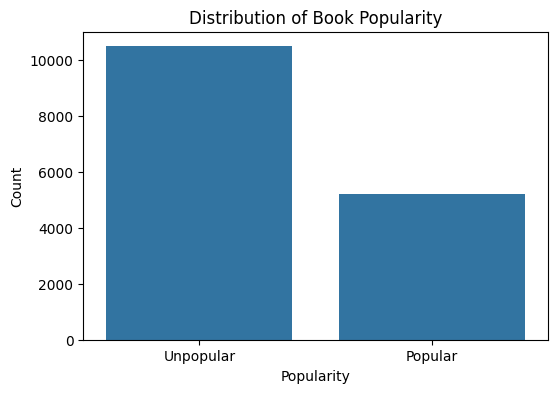

In [ ]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=books, x="popularity")
plt.title("Distribution of Book Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

## 4. Basic data cleaning

We remove duplicate rows and check the target variable.

The target column is `popularity`.


In [ ]:
# Remove duplicate rows
books = books.drop_duplicates()

# Keep only rows where target is not missing
books = books.dropna(subset=["popularity"])

# Check result
books.shape

(12425, 9)

## 5. Feature engineering: review helpfulness

The column `review/helpfulness` has values like:

```text
2/5
10/12
0/0
```

We will create three useful numeric features:

- `num_helpful`: number of helpful votes
- `num_reviews`: total number of votes
- `perc_helpful_reviews`: helpfulness percentage


In [ ]:
def extract_helpfulness(df):
    df = df.copy()

    # Split "helpful/total" into two columns
    helpful_split = df["review/helpfulness"].fillna("0/0").str.split("/", expand=True)

    df["num_helpful"] = pd.to_numeric(helpful_split[0], errors="coerce").fillna(0)
    df["num_reviews"] = pd.to_numeric(helpful_split[1], errors="coerce").fillna(0)

    # Avoid division by zero
    df["perc_helpful_reviews"] = np.where(
        df["num_reviews"] > 0,
        df["num_helpful"] / df["num_reviews"],
        0
    )

    return df

books = extract_helpfulness(books)

books[["review/helpfulness", "num_helpful", "num_reviews", "perc_helpful_reviews"]].head()

,review/helpfulness,num_helpful,num_reviews,perc_helpful_reviews
0,2/3,2,3,0.666667
1,0/0,0,0,0.000000
2,17/19,17,19,0.894737
3,0/1,0,1,0.000000
4,18/20,18,20,0.900000


## 6. Create a combined text feature

The dataset contains several text columns:

- `title`
- `authors`
- `categories`
- `review/summary`
- `review/text`
- `description`

Instead of using only a few positive words, we combine all useful text into one column called `combined_text`.

Then, we will use **TF-IDF** to transform this text into numeric features.


In [ ]:
text_columns = [
    "title",
    "authors",
    "categories",
    "review/summary",
    "review/text",
    "description"
]

for col in text_columns:
    books[col] = books[col].fillna("").astype(str).str.lower()

books["combined_text"] = (
    books["title"] + " " +
    books["authors"] + " " +
    books["categories"] + " " +
    books["review/summary"] + " " +
    books["review/text"] + " " +
    books["description"]
)

books[["combined_text"]].head()

,combined_text
0,we band of angels: the untold story of america...
1,prayer that brings revival: interceding for go...
2,the mystical journey from jesus to christ 'mua...
3,death row 'lynden harris' 'social science' ben...
4,sound and form in modern poetry: second editio...


## 7. Prepare features and target

We use:

### Text feature
- `combined_text`

### Numeric features
- `price`
- `num_helpful`
- `num_reviews`
- `perc_helpful_reviews`

### Target
- `popularity`


In [ ]:
# Convert price to numeric
books["price"] = pd.to_numeric(books["price"], errors="coerce").fillna(0)

# Features
features = ["combined_text", "price", "num_helpful", "num_reviews", "perc_helpful_reviews"]
X = books[features]

# Target
y = books["popularity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12425, 5)
y shape: (12425,)


## 8. Train-test split

We split the data into:

- **70% training data**
- **30% test data**

We use `stratify=y` to keep the same class distribution in both training and test sets.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 8697
Testing rows: 3728


## 9. Build the ML pipeline

We build one clean pipeline containing:

### Text preprocessing
`TfidfVectorizer`

It converts text into numeric values based on word importance.

### Numeric preprocessing
`StandardScaler`

It standardizes numeric variables.

### Model
`LogisticRegression`

This model is very good for text classification problems.

We also use:

```python
class_weight="balanced"
```

because the dataset contains more `Unpopular` books than `Popular` books.


In [ ]:
# Define columns
text_feature = "combined_text"
numeric_features = ["price", "num_helpful", "num_reviews", "perc_helpful_reviews"]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2)), text_feature),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

# Full ML pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'combined_text'),
                                                 ('num', StandardScaler(),
                                                  ['price', 'num_helpful',
                                                   'num_reviews',
                                                   'perc_helpful_reviews'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 10. Train the model

The pipeline will automatically:

1. Transform text using TF-IDF
2. Scale numeric features
3. Train the classifier


In [ ]:
model.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


## 11. Evaluate the model

Accuracy alone is not enough, especially because the dataset is imbalanced.

We evaluate using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- ROC-AUC score


In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(accuracy, 4))

Test Accuracy: 0.7052


In [ ]:
# Detailed classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Popular       0.63      0.74      0.68      1569
   Unpopular       0.78      0.68      0.73      2159

    accuracy                           0.71      3728
   macro avg       0.70      0.71      0.70      3728
weighted avg       0.72      0.71      0.71      3728



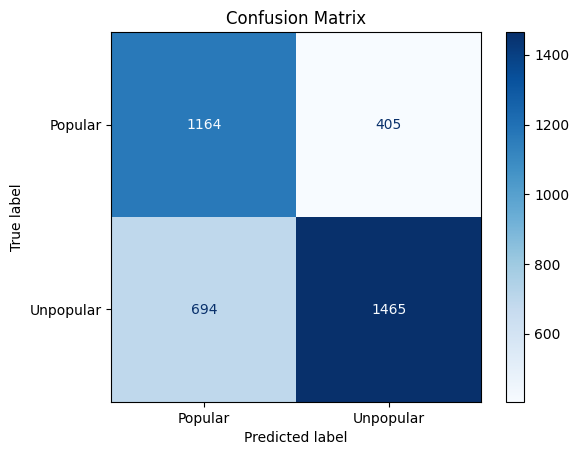

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ROC-AUC score
# We calculate probability of the positive class: Popular
if hasattr(model, "predict_proba"):
    popular_index = list(model.classes_).index("Popular")
    y_proba = model.predict_proba(X_test)[:, popular_index]

    y_test_binary = (y_test == "Popular").astype(int)
    auc_score = roc_auc_score(y_test_binary, y_proba)

    print("ROC-AUC Score:", round(auc_score, 4))

## 12. Compare several Machine Learning models

In a real Machine Learning project, we should not test only one model.  
Here, we compare four strong approaches:

1. **Logistic Regression with TF-IDF**: very strong baseline for text classification.
2. **Random Forest**: useful for tabular/numeric features and non-linear patterns.
3. **Gradient Boosting / XGBoost idea**: powerful boosting family; here we use `HistGradientBoostingClassifier` from scikit-learn as a clean alternative.
4. **Naive Bayes**: simple and fast model, often strong for text classification.

We compare them using:

- Accuracy
- F1-score macro
- F1-score weighted

The **F1-score** is important because the target is imbalanced: there are more `Unpopular` books than `Popular` books.


In [ ]:
# Model comparison
# We keep the same text and numeric features.

text_feature = "combined_text"
numeric_features = ["price", "num_helpful", "num_reviews", "perc_helpful_reviews"]

# Standard preprocessor: good for Logistic Regression, Random Forest, and Gradient Boosting
preprocessor_standard = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2)), text_feature),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

# Naive Bayes needs non-negative values, so we use MinMaxScaler instead of StandardScaler
preprocessor_nb = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2)), text_feature),
        ("num", MinMaxScaler(), numeric_features)
    ],
    remainder="drop"
)

# Gradient Boosting needs dense data, so we limit TF-IDF features to keep execution reasonable
preprocessor_boosting = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=800, stop_words="english", ngram_range=(1, 2)), text_feature),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

models = {
    "Logistic Regression + TF-IDF": Pipeline(steps=[
        ("preprocessor", preprocessor_standard),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_standard),
        ("classifier", RandomForestClassifier(
            n_estimators=120,
            max_depth=50,
            min_samples_split=5,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_boosting),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.08,
            random_state=42
        ))
    ]),

    "Naive Bayes": Pipeline(steps=[
        ("preprocessor", preprocessor_nb),
        ("classifier", MultinomialNB())
    ])
}

results = []

for model_name, candidate_model in models.items():
    print(f"Training: {model_name}")
    candidate_model.fit(X_train, y_train)
    y_pred_candidate = candidate_model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred_candidate),
        "F1 Macro": f1_score(y_test, y_pred_candidate, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred_candidate, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Weighted", ascending=False)
results_df


Training: Logistic Regression + TF-IDF
Training: Random Forest
Training: Gradient Boosting
Training: Naive Bayes


,Model,Accuracy,F1 Macro,F1 Weighted
0,Logistic Regression + TF-IDF,0.705204,0.703269,0.707061
1,Random Forest,0.704399,0.690501,0.700881
2,Gradient Boosting,0.695279,0.683267,0.693029
3,Naive Bayes,0.676770,0.642450,0.659982


### How to choose the best model

For this project, I recommend choosing the model with the best **F1 Weighted** score, not only the best accuracy.

Why?

Because the dataset is imbalanced. If we only use accuracy, the model may look good because it predicts the majority class `Unpopular` very often.

In many text classification projects, **Logistic Regression with TF-IDF** and **Naive Bayes** are very strong baselines. Random Forest can work, but it is not always the best choice for sparse text data. Gradient Boosting can be powerful, but it may be slower with many TF-IDF features.


In [ ]:
# Select the best model automatically based on F1 Weighted
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)
print(results_df.iloc[0])


Best model: Logistic Regression + TF-IDF
Model          Logistic Regression + TF-IDF
Accuracy                           0.705204
F1 Macro                           0.703269
F1 Weighted                        0.707061
Name: 0, dtype: object


### Optional: XGBoost version

If you have `xgboost` installed, you can test `XGBClassifier`.  
XGBoost is part of the Gradient Boosting family and is often very powerful.

If this cell gives an installation error, you can install it with:

```bash
pip install xgboost
```


In [ ]:
!pip install xgboost

In [ ]:
# Optional XGBoost model
# Run this cell only if xgboost is installed.

try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    xgb_model = Pipeline(steps=[
        ("preprocessor", preprocessor_standard),
        ("classifier", XGBClassifier(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42
        ))
    ])

    xgb_model.fit(X_train, y_train_encoded)
    y_pred_xgb_encoded = xgb_model.predict(X_test)
    y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

    print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("XGBoost F1 Weighted:", f1_score(y_test, y_pred_xgb, average="weighted"))
    print(classification_report(y_test, y_pred_xgb))

except Exception as e:
    print("XGBoost is not available or produced an error:")
    print(e)


XGBoost Accuracy: 0.7127145922746781
XGBoost F1 Weighted: 0.7100293664522261
              precision    recall  f1-score   support

     Popular       0.68      0.61      0.64      1569
   Unpopular       0.73      0.79      0.76      2159

    accuracy                           0.71      3728
   macro avg       0.71      0.70      0.70      3728
weighted avg       0.71      0.71      0.71      3728



## 16. Test the selected Logistic Regression model with a new example

This simulates what will happen later inside the Flask application.

A user will enter book information, then the model will return:

- Popular
- Unpopular


In [ ]:
new_book = pd.DataFrame({
    "combined_text": [
        "amazing fantasy book with excellent story and great characters. readers love this book and recommend it."
    ],
    "price": [15.99],
    "num_helpful": [20],
    "num_reviews": [25],
    "perc_helpful_reviews": [20 / 25]
})

prediction = model.predict(new_book)
probability = model.predict_proba(new_book)

print("Prediction:", prediction[0])
print("Classes:", model.classes_)
print("Probabilities:", probability[0])

Prediction: Popular
Classes: ['Popular' 'Unpopular']
Probabilities: [0.95967122 0.04032878]


## 17. Save the model for Flask

We save the complete pipeline, including:

- TF-IDF vectorizer
- Scaler
- Logistic Regression model

This is important because Flask must use the **same preprocessing steps** used during training.


In [ ]:
joblib.dump(model, "book_popularity_model.pkl")
print("Model saved as book_popularity_model.pkl")

Model saved as book_popularity_model.pkl


In [ ]:
joblib.dump(TfidfVectorizer, "tfidf.pkl")
joblib.dump(label_encoder, "encoder.pkl")

['encoder.pkl']

# Final conclusion

In this notebook, we created a clean ML pipeline for book popularity prediction.

## What we did

- Loaded and inspected the dataset
- Cleaned the data
- Created helpfulness features
- Combined text columns
- Used TF-IDF for text representation
- Trained a Logistic Regression model
- Evaluated the model properly
- Saved the model for a future Flask application

This version is cleaner and more realistic than manually counting only positive words.
